In [1]:
# ---------------------------------------------------------
# STEP 1: Setup & Ingestion
# Purpose: Load ML-ready listing features and inspect schema
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve project root (assumes notebook is in /notebooks)
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
gold_dir = project_root / "data" / "gold"

# Load ML feature table
df = pd.read_parquet(gold_dir / "ml_listing_features.parquet")

# Basic inspection
print(f"✅ Loaded {len(df):,} listings")
df.info()
df.head()

✅ Loaded 94,559 listings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94559 entries, 0 to 94558
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   id                         94559 non-null  int64         
 1   host_id                    94559 non-null  int64         
 2   room_type                  94559 non-null  category      
 3   neighbourhood_cleansed     94559 non-null  category      
 4   price                      60341 non-null  float64       
 5   host_is_superhost          94559 non-null  int64         
 6   host_response_rate         60416 non-null  Float64       
 7   review_scores_rating       94559 non-null  float64       
 8   beds                       60282 non-null  float64       
 9   accommodates               94559 non-null  int64         
 10  minimum_nights             94559 non-null  int64         
 11  maximum_nights             94559 non-null 

,id,host_id,room_type,neighbourhood_cleansed,price,host_is_superhost,host_response_rate,review_scores_rating,beds,accommodates,...,number_of_reviews,future_calendar_days,future_available_days,future_avg_price,future_occupancy_rate,review_count,first_review_date,last_review_date,reviews_per_month,beds_imputed
0,91031,491004,Entire home/apt,Wandsworth,94.0,0,88.0,4.23,1.0,2,...,25,365.0,72.0,99.0,0.802740,25,2011-05-03,2025-03-05,0.148368,1.0
1,91287,493497,Entire home/apt,Islington,NaN,0,100.0,4.51,NaN,4,...,66,365.0,0.0,185.0,1.000000,66,2011-05-17,2024-12-04,0.400000,2.0
2,92352,497172,Entire home/apt,Islington,NaN,1,100.0,4.86,NaN,2,...,73,365.0,0.0,110.0,1.000000,73,2016-12-11,2024-12-02,0.751802,2.0
3,92399,497366,Entire home/apt,Islington,86.0,1,100.0,4.84,1.0,2,...,317,365.0,288.0,100.0,0.210959,317,2011-07-05,2025-02-27,1.907341,1.0
4,93015,499704,Entire home/apt,Hammersmith and Fulham,175.0,0,<NA>,4.85,3.0,5,...,40,365.0,33.0,180.0,0.909589,40,2012-02-01,2024-11-14,0.256959,3.0


In [2]:
# ---------------------------------------------------------
# STEP 2: Initial Data Audit
# Purpose: Check nulls, dtypes, and basic distributions
# ---------------------------------------------------------

# Null counts
nulls = df.isnull().sum().sort_values(ascending=False)
print("🔍 Nulls per column:\n", nulls[nulls > 0])

# Descriptive stats
df.describe().T

# Quick look at categorical flags
print("🧮 Unique room types:", df["room_type"].unique())
print("🧮 Unique neighbourhoods:", df["neighbourhood_cleansed"].nunique())

🔍 Nulls per column:
 beds                       34277
price                      34218
host_response_rate         34143
last_review_date           24244
first_review_date          24244
future_calendar_days           5
estimated_revenue_l365d        5
future_available_days          5
future_avg_price               5
future_occupancy_rate          5
beds_imputed                   5
dtype: int64
🧮 Unique room types: ['Entire home/apt', 'Private room', 'Hotel room', 'Shared room']
Categories (4, object): ['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']
🧮 Unique neighbourhoods: 33


In [3]:
df.describe()

,id,host_id,price,host_is_superhost,host_response_rate,review_scores_rating,beds,accommodates,minimum_nights,maximum_nights,...,number_of_reviews,future_calendar_days,future_available_days,future_avg_price,future_occupancy_rate,review_count,first_review_date,last_review_date,reviews_per_month,beds_imputed
count,9.455900e+04,9.455900e+04,60341.000000,94559.000000,60416.0,94559.000000,60282.000000,94559.000000,94559.000000,9.455900e+04,...,94559.000000,94554.000000,94554.000000,94554.000000,94554.000000,94559.0,70315,70315,94559.000000,94554.000000
mean,6.066726e+17,2.003118e+08,185.482624,0.177593,92.675401,3.489244,1.932102,3.299337,5.482704,6.215041e+03,...,20.434491,365.002232,134.234670,269.660089,0.632230,20.434438,2021-08-28 16:12:38.552229120,2023-07-23 08:50:12.500889088,1.422220,1.820209
min,1.391300e+04,2.594000e+03,6.000000,0.000000,0.0,0.000000,0.000000,1.000000,1.000000,1.000000e+00,...,0.000000,350.000000,0.000000,0.000000,0.000000,0.0,2009-12-21 00:00:00,2011-07-02 00:00:00,0.000000,1.000000
25%,2.809901e+07,2.572771e+07,71.000000,0.000000,99.0,0.000000,1.000000,2.000000,1.000000,6.000000e+01,...,0.000000,365.000000,0.000000,67.000000,0.263014,0.0,2018-12-30 00:00:00,2023-06-27 00:00:00,0.000000,1.000000
50%,7.511326e+17,1.057565e+08,120.000000,0.000000,100.0,4.680000,1.000000,2.000000,2.000000,3.650000e+02,...,4.000000,365.000000,88.000000,120.000000,0.758904,4.0,2022-12-04 00:00:00,2024-10-31 00:00:00,0.530973,2.000000
75%,1.141072e+18,3.760111e+08,197.000000,0.000000,100.0,4.960000,2.000000,4.000000,4.000000,1.125000e+03,...,19.000000,365.000000,269.000000,200.000000,1.000000,19.0,2024-05-06 00:00:00,2025-02-03 00:00:00,1.714286,2.000000
max,1.368871e+18,6.819521e+08,74100.000000,1.000000,100.0,5.000000,50.000000,16.000000,1125.000000,5.248556e+08,...,1791.000000,366.000000,366.000000,80000.000000,1.000000,1791.0,2025-03-14 00:00:00,2025-03-15 00:00:00,90.000000,50.000000
std,5.481489e+17,2.068400e+08,604.807337,0.382172,21.114495,2.090986,1.439265,2.063247,23.157895,1.707381e+06,...,48.854856,0.464565,136.288298,1069.277493,0.373383,48.854875,NaN,NaN,3.202008,1.175600


In [4]:
# REMAINING Missingness Cleanup Strategy

#DROP
df = df.drop(columns=[
    "beds",                # replaced by beds_imputed
    "price",               # replaced by future_avg_price
    "first_review_date",   # not needed for clustering
    "last_review_date"     # same
])

df.head()

,id,host_id,room_type,neighbourhood_cleansed,host_is_superhost,host_response_rate,review_scores_rating,accommodates,minimum_nights,maximum_nights,...,estimated_occupancy_l365d,number_of_reviews_ltm,number_of_reviews,future_calendar_days,future_available_days,future_avg_price,future_occupancy_rate,review_count,reviews_per_month,beds_imputed
0,91031,491004,Entire home/apt,Wandsworth,0,88.0,4.23,2,6,89,...,48,4,25,365.0,72.0,99.0,0.802740,25,0.148368,1.0
1,91287,493497,Entire home/apt,Islington,0,100.0,4.51,4,1,365,...,37,4,66,365.0,0.0,185.0,1.000000,66,0.400000,2.0
2,92352,497172,Entire home/apt,Islington,1,100.0,4.86,2,3,121,...,129,14,73,365.0,0.0,110.0,1.000000,73,0.751802,2.0
3,92399,497366,Entire home/apt,Islington,1,100.0,4.84,2,1,365,...,239,26,317,365.0,288.0,100.0,0.210959,317,1.907341,1.0
4,93015,499704,Entire home/apt,Hammersmith and Fulham,0,<NA>,4.85,5,5,1125,...,30,3,40,365.0,33.0,180.0,0.909589,40,0.256959,3.0


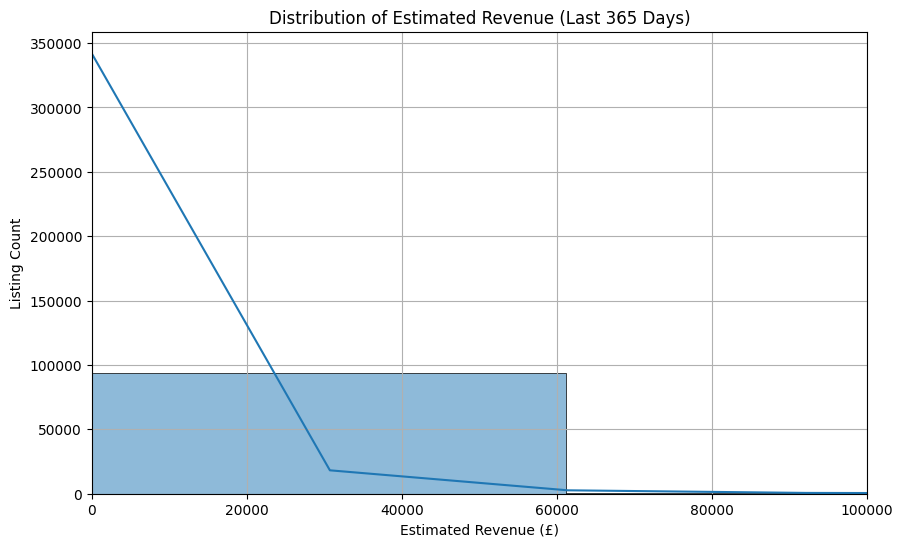

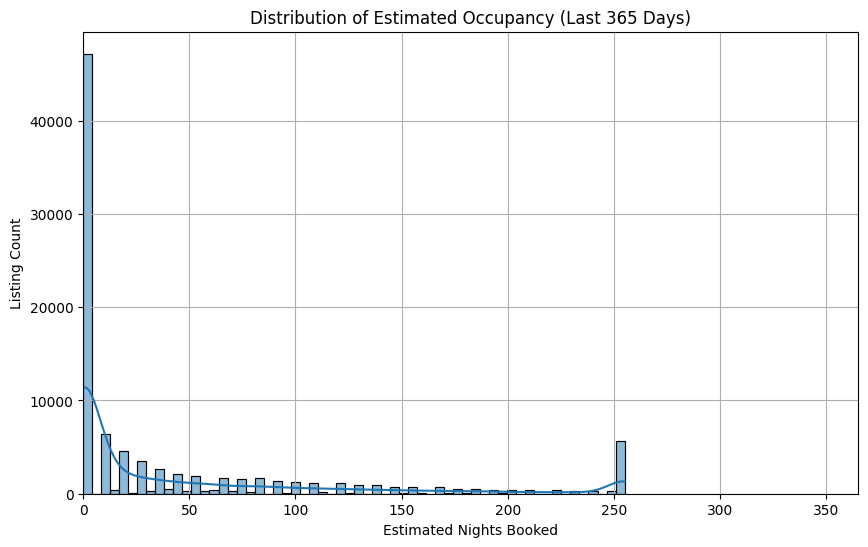

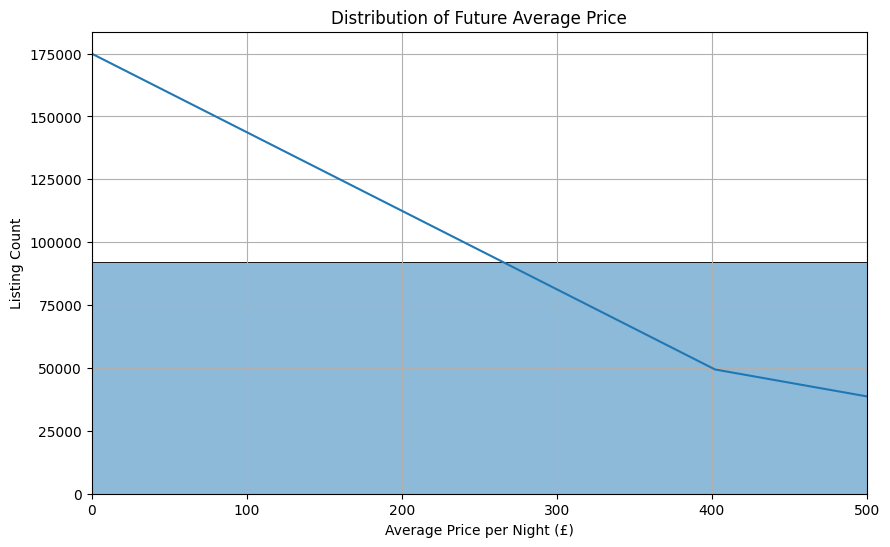

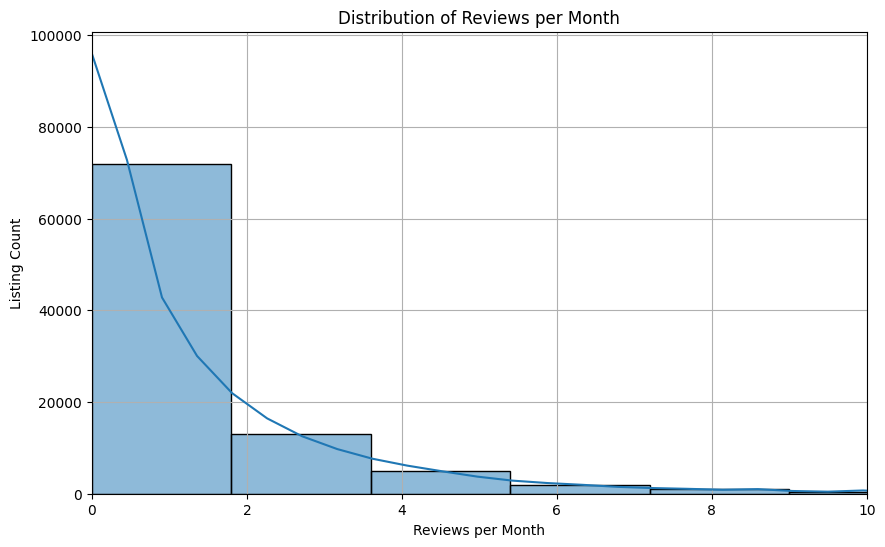

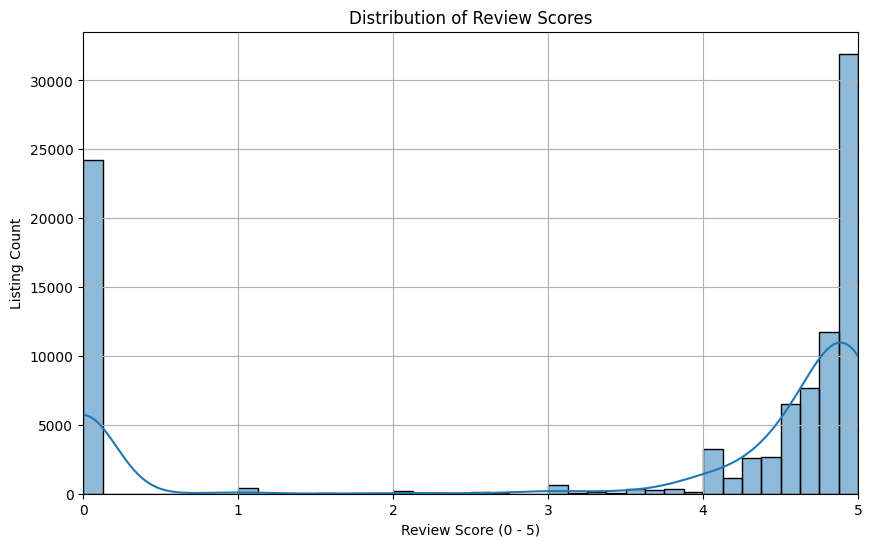

In [5]:
# ---------------------------------------------------------
# Distribution of Estimated Revenue
# Purpose: Understand how much listings earn over a year.
# Reveals skew, outliers, and typical earning bands.
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.histplot(df["estimated_revenue_l365d"], bins=100, kde=True)

# Axis and styling
plt.title("Distribution of Estimated Revenue (Last 365 Days)")
plt.xlabel("Estimated Revenue (£)")
plt.ylabel("Listing Count")
plt.xlim(0, 100000)  # Focus on realistic revenue range; adjust if needed
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# Distribution of Estimated Occupancy
# Purpose: Show how many nights listings were booked last year.
# Helps distinguish full-time vs seasonal or inactive hosts.
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.histplot(df["estimated_occupancy_l365d"], bins=60, kde=True)

# Axis and styling
plt.title("Distribution of Estimated Occupancy (Last 365 Days)")
plt.xlabel("Estimated Nights Booked")
plt.ylabel("Listing Count")
plt.xlim(0, 365)  # Full-year range
plt.grid(True)
plt.show()

# ---------------------------------------------------------
# Distribution of Future Average Price
# Purpose: Explore host pricing strategy across listings.
# Reveals budget vs premium positioning and pricing outliers.
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.histplot(df["future_avg_price"], bins=80, kde=True)

# Axis and styling
plt.title("Distribution of Future Average Price")
plt.xlabel("Average Price per Night (£)")
plt.ylabel("Listing Count")
plt.xlim(0, 500)  # Focus on realistic nightly rates
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# Distribution of Reviews per Month
# Purpose: Gauge listing engagement velocity.
# High review velocity often correlates with demand and visibility.
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.histplot(df["reviews_per_month"], bins=50, kde=True)

# Axis and styling
plt.title("Distribution of Reviews per Month")
plt.xlabel("Reviews per Month")
plt.ylabel("Listing Count")
plt.xlim(0, 10)  # Most listings fall within this range
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# Distribution of Review Scores
# Purpose: Assess guest satisfaction across listings.
# Helps identify quality tiers and potential service gaps.
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.histplot(df["review_scores_rating"], bins=40, kde=True)

# Axis and styling
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score (0 - 5)")
plt.ylabel("Listing Count")
plt.xlim(0, 5)
plt.grid(True)
plt.show()



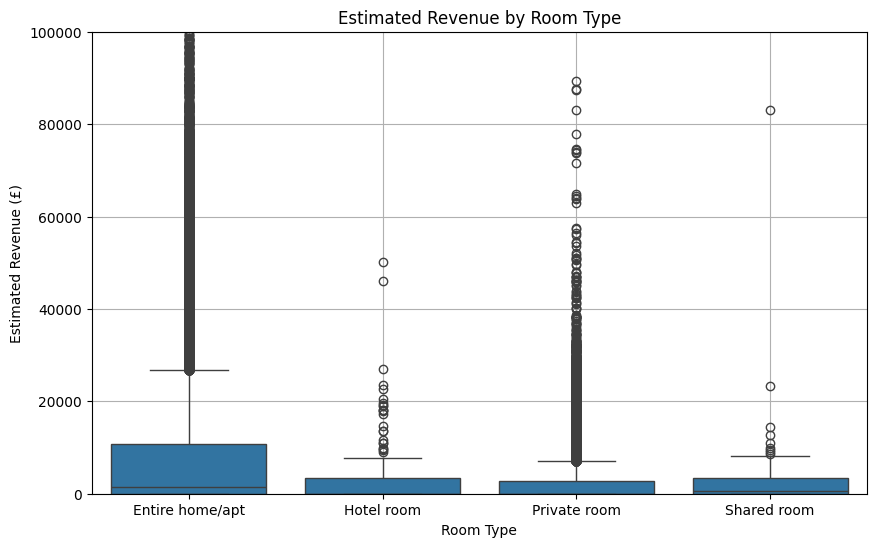

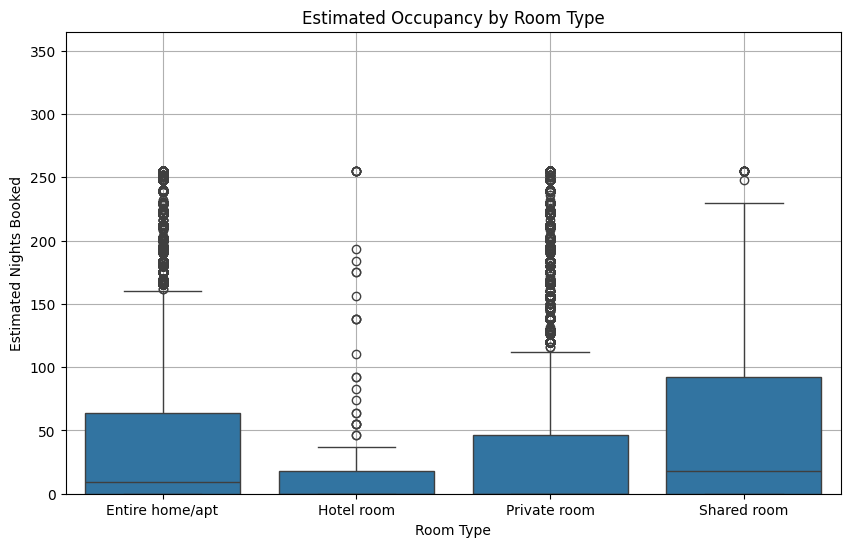

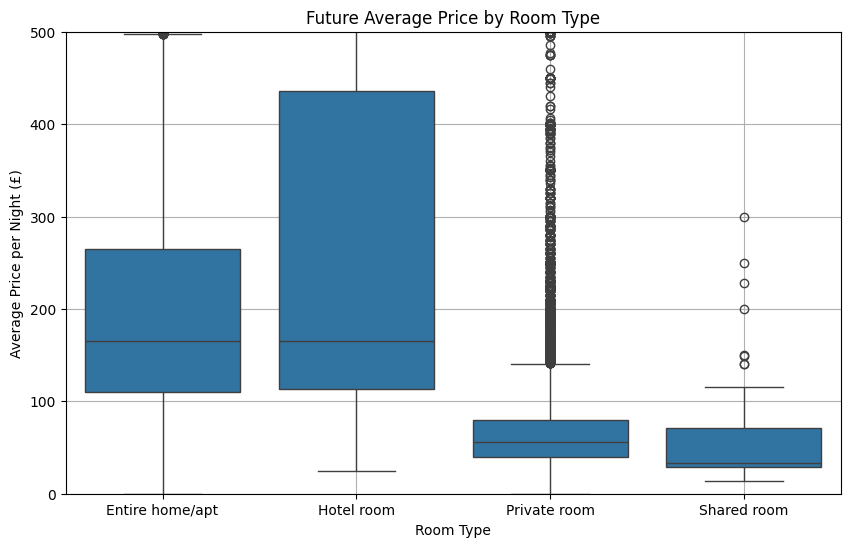

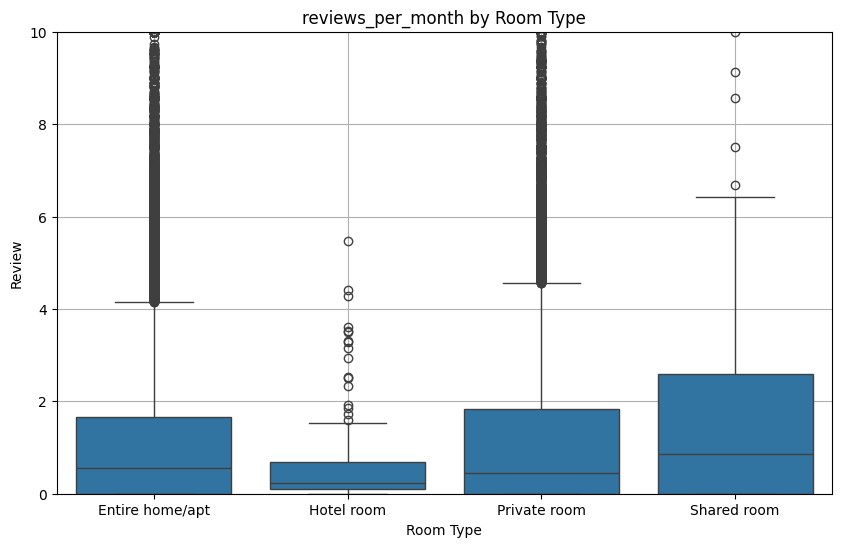

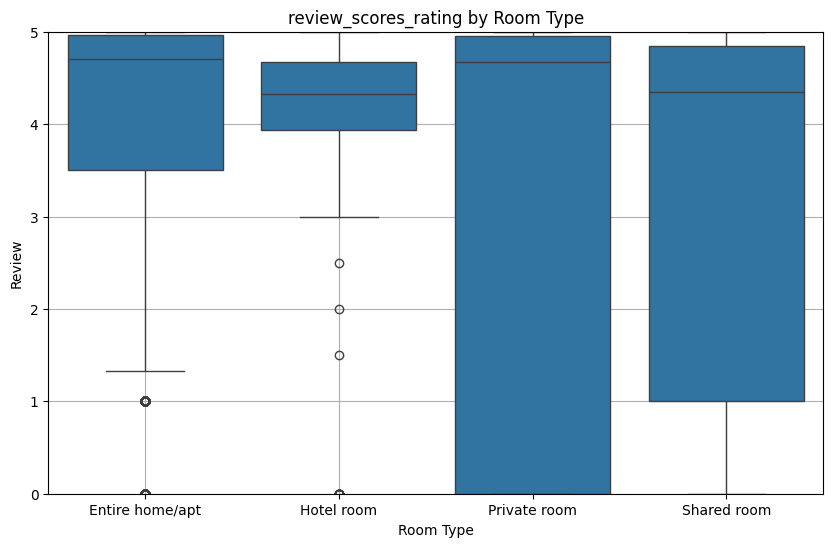

In [6]:
# ---------------------------------------------------------
# Boxplot: Estimated Revenue by Room Type
# Purpose: Compare annual revenue across listing types.
# Reveals which room types tend to earn more and highlights outliers.
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="room_type", y="estimated_revenue_l365d")
plt.title("Estimated Revenue by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Estimated Revenue (£)")
plt.ylim(0, 100000)  # Optional: cap to focus on typical range
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# Boxplot: Estimated Occupancy by Room Type
# Purpose: Compare booking frequency across room types.
# Helps identify which types are most in demand.
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="room_type", y="estimated_occupancy_l365d")
plt.title("Estimated Occupancy by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Estimated Nights Booked")
plt.ylim(0, 365)
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# Boxplot: Future Average Price by Room Type
# Purpose: Explore pricing strategy across room types.
# Reveals budget vs premium positioning.
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="room_type", y="future_avg_price")
plt.title("Future Average Price by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Average Price per Night (£)")
plt.ylim(0, 500)
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# Boxplot: reviews_per_month by Room Type
# Purpose: Assess engagement velocity across room types.
# High review velocity often correlates with visibility and demand.
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="room_type", y="reviews_per_month")
plt.title("reviews_per_month by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Review")
plt.ylim(0, 10)
plt.grid(True)
plt.show()


# ---------------------------------------------------------
# Boxplot: review_scores_rating by Room Type
# Purpose: Assess engagement velocity across room types.
# High review velocity often correlates with visibility and demand.
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="room_type", y="review_scores_rating")
plt.title("review_scores_rating by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Review")
plt.ylim(0, 5)
plt.grid(True)
plt.show()


📊 What the Plot Shows
- X-axis: Room types — Entire home/apt, Hotel room, Private room, Shared room
- Y-axis: Estimated revenue over the past 12 months (in £)
- Each box shows:
- Median: The horizontal line inside the box
- Interquartile range (IQR): The box itself (middle 50% of listings)
- Whiskers: Range of typical values (excluding outliers)
- Dots: Outliers — listings earning significantly more than the norm

🧠 What It Means
1. Entire home/apt dominates
- Highest median revenue and widest spread
- Many outliers earning £50k–£100k+
- These listings are likely full-time rentals or premium properties
2. Private rooms are modest earners
- Lower median and tighter IQR
- Still viable, but not high-revenue — likely used for supplemental income
3. Hotel rooms are surprisingly flat
- Narrow distribution, lower median than expected
- Could reflect limited data or standardized pricing
4. Shared rooms are niche
- Lowest median and smallest spread
- Likely low-demand or low-price offerings — not a major revenue driver

💡 Strategic Takeaways
- If you're segmenting listings by business potential, room type is a strong classifier
- Entire homes offer the most upside — ideal for targeting high-value hosts
- Private/shared rooms may be better suited for budget or community-focused strategies
- Hotel rooms might need separate treatment — they behave differently

Let me know if you want to overlay superhost status, filter by city, or compare this to occupancy or pricing. You're turning raw data into business insight.

💡 Strategic Takeaways
- If you're segmenting listings by business potential, room type is a strong classifier
- Entire homes offer the most upside — ideal for targeting high-value hosts
- Private/shared rooms may be better suited for budget or community-focused strategies
- Hotel rooms might need separate treatment — they behave differently

Let me know if you want to overlay superhost status, filter by city, or compare this to occupancy or pricing. You're turning raw data into business insight.



📊 What the Plot Shows
- X-axis: Room types — Entire home/apt, Hotel room, Private room, Shared room
- Y-axis: Estimated number of nights booked over the past 12 months
- Each box shows:
- Median: Typical occupancy for that room type
- IQR: Spread of the middle 50% of listings
- Whiskers and outliers: Range and extreme performers


🧠 What It Means
1. Entire home/apt
- High median occupancy and wide spread
- Suggests strong demand and diverse usage — from casual hosts to full-time operators
- Many listings booked 200+ nights, indicating year-round availability
2. Private room
- Lower median occupancy, tighter IQR
- Likely used for supplemental income or part-time hosting
- Less variability — more predictable usage patterns
3. Hotel room
- Surprisingly low median and narrow spread
- Could reflect limited data, standardized availability, or low platform engagement
- May need separate modeling or exclusion from clustering
4. Shared room
- High variability and some very high occupancy outliers
- Possibly used for long-term stays or communal setups
- Niche but interesting — worth profiling separately

💡 Strategic Takeaways
- Occupancy is a strong behavioral signal — it reflects both demand and host commitment
- Room type clearly influences booking patterns — useful for segmentation
- Shared and hotel rooms may need special treatment in clustering due to their unique distributions
- Combining this with revenue and pricing gives you a full picture of listing strategy
Let me know if you want to overlay superhost status or compare this to pricing next. You're building a narrative that’s both data-rich and business-savvy.


💡 Strategic Takeaways
- Occupancy is a strong behavioral signal — it reflects both demand and host commitment
- Room type clearly influences booking patterns — useful for segmentation
- Shared and hotel rooms may need special treatment in clustering due to their unique distributions
- Combining this with revenue and pricing gives you a full picture of listing strategy


💰 Top Plot: Future Average Price by Room Type
📊 What It Shows
- X-axis: Room types — Entire home/apt, Hotel room, Private room, Shared room
- Y-axis: Average nightly price (future-facing)
- Each box shows:
- Median price
- IQR (middle 50% of listings)
- Whiskers and outliers
🧠 What It Means
- Entire home/apt and Hotel room have the highest median prices — positioned as premium offerings
- Private rooms show wide variability — some priced competitively, others unusually high (likely boutique or mispriced)
- Shared rooms are consistently low-priced — budget-focused, with little pricing power
💡 Strategic Insight
- Room type is a strong signal for pricing segmentation
- Private rooms may need further profiling — they span both budget and premium zones
- Shared rooms are unlikely to drive high revenue, but may offer high occupancy or long stays


💬 Bottom Plot: Reviews per Month by Room Type
📊 What It Shows
- X-axis: Room types
- Y-axis: Monthly review velocity
- Indicates how frequently listings receive guest feedback
🧠 What It Means
- Private rooms have the highest median review velocity — likely due to affordability and high turnover
- Entire homes and Hotel rooms show lower engagement — possibly longer stays or fewer guests per booking
- Shared rooms have the lowest review activity — niche usage or low visibility
💡 Strategic Insight
- Review velocity is a proxy for demand and visibility
- Private rooms may be ideal for short-stay, high-churn strategies
- Entire homes may benefit from fewer but higher-value bookings

Together, these plots help you understand how room type influences both pricing and engagement — critical for clustering, segmentation, and business strategy. Let me know if you want to overlay superhost status or filter by city next. You're building a portfolio that reads like a market analyst’s playbook.


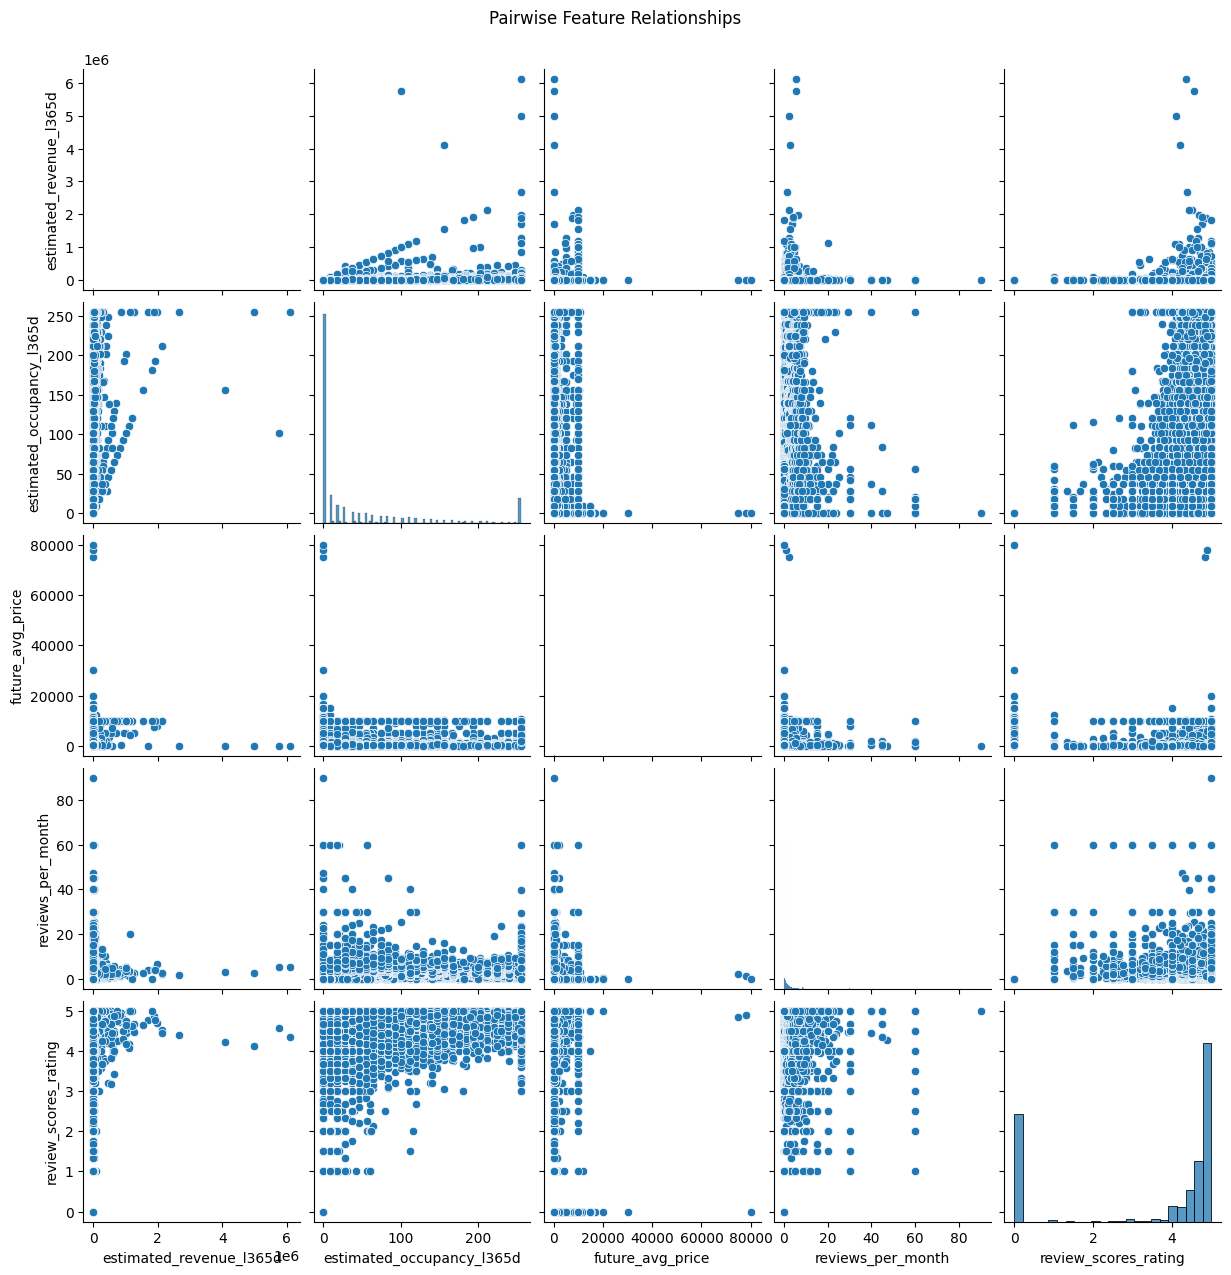

In [7]:
# ---------------------------------------------------------
# Pairplot: Key Feature Relationships
# Purpose: Explore pairwise relationships between core metrics.
# Helps identify linear/nonlinear trends, clusters, and correlations.
# Includes review_scores_rating to assess satisfaction vs performance.
# ---------------------------------------------------------

sns.pairplot(df[[
    "estimated_revenue_l365d",       # Annual revenue signal
    "estimated_occupancy_l365d",     # Booking frequency
    "future_avg_price",              # Host pricing strategy
    "reviews_per_month",             # Engagement velocity
    "review_scores_rating"           # Guest satisfaction
]])

# Add a title above the grid
plt.suptitle("Pairwise Feature Relationships", y=1.02)

# Show the plot
plt.show()

🔍 Key Takeaways from the Pairplot
1. Revenue vs Occupancy: Strong Positive Correlation
- Listings with higher occupancy tend to earn more — no surprise, but it confirms that booking frequency is a key revenue driver
- Suggests that occupancy could be a proxy for demand or host commitment
2. Revenue vs Price: Weak or No Clear Correlation
- High nightly price doesn’t guarantee high revenue — likely because expensive listings may have lower occupancy
- Reinforces the idea that pricing strategy must be paired with availability and demand
3. Reviews per Month vs Revenue/Occupancy: Moderate Positive Relationship
- Listings with frequent reviews tend to be more booked and earn more
- Indicates that review velocity is a solid engagement signal, possibly tied to visibility or guest satisfaction
4. Review Scores Rating: Weakly Correlated Across the Board
- Most listings cluster around high scores (4.5–5), so there's limited variance
- Doesn’t strongly predict revenue, occupancy, or review velocity — but could still help flag quality tiers or filter out poor performers

🧠 Strategic Implications
- Occupancy is your strongest behavioral anchor — it drives revenue and reflects listing activity
- Price alone is not predictive — it needs to be contextualized with occupancy and review velocity
- Review scores are saturated — useful for filtering, but not for clustering unless you isolate low performers
- Reviews per month is a sleeper hit — it captures engagement and churn better than total review count


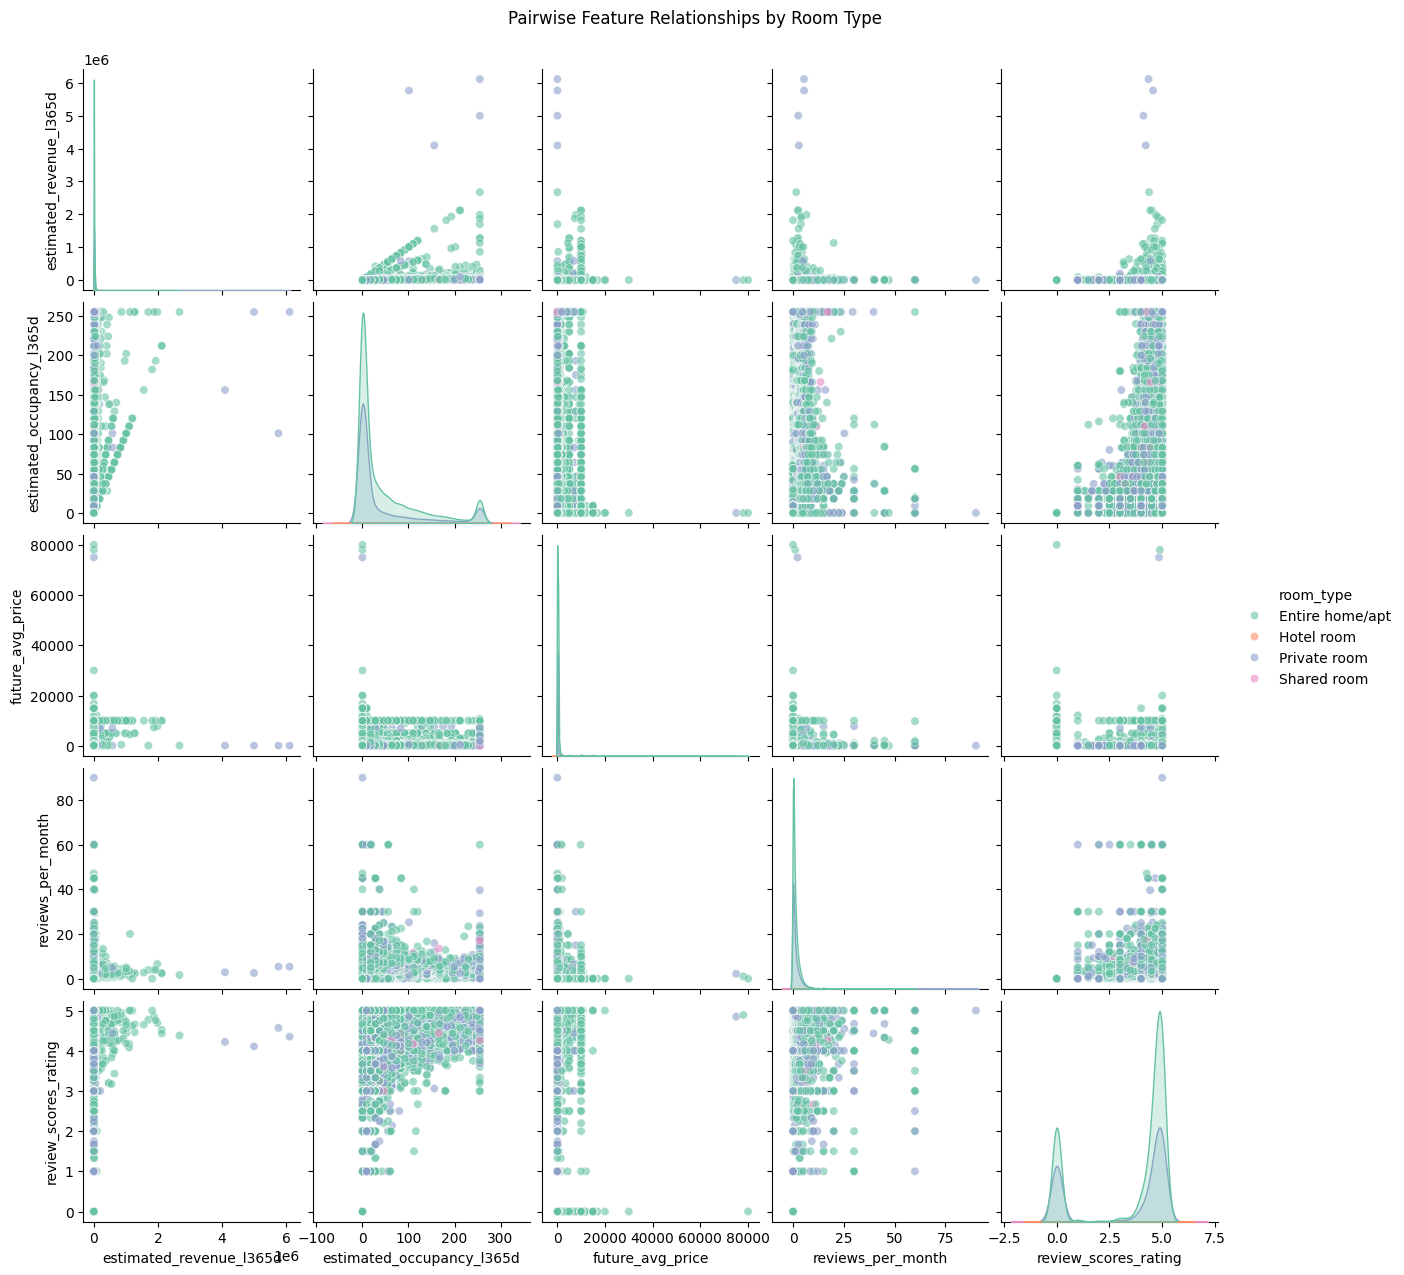

In [8]:
# ---------------------------------------------------------
# Pairplot: Feature Relationships Colored by Room Type
# Purpose: Explore how core metrics vary across room types.
# Adds hue to reveal behavioral differences between listing categories.
# Useful for spotting segmentation patterns and cluster potential.
# ---------------------------------------------------------

sns.pairplot(
    df[[
        "estimated_revenue_l365d",
        "estimated_occupancy_l365d",
        "future_avg_price",
        "reviews_per_month",
        "review_scores_rating",
        "room_type"  # Used for coloring
    ]],
    hue="room_type",        # Color points by room type
    palette="Set2",         # Soft, readable color palette
    plot_kws={"alpha": 0.6} # Slight transparency for overlap
)

# Add a title above the grid
plt.suptitle("Pairwise Feature Relationships by Room Type", y=1.02)

# Show the plot
plt.show()

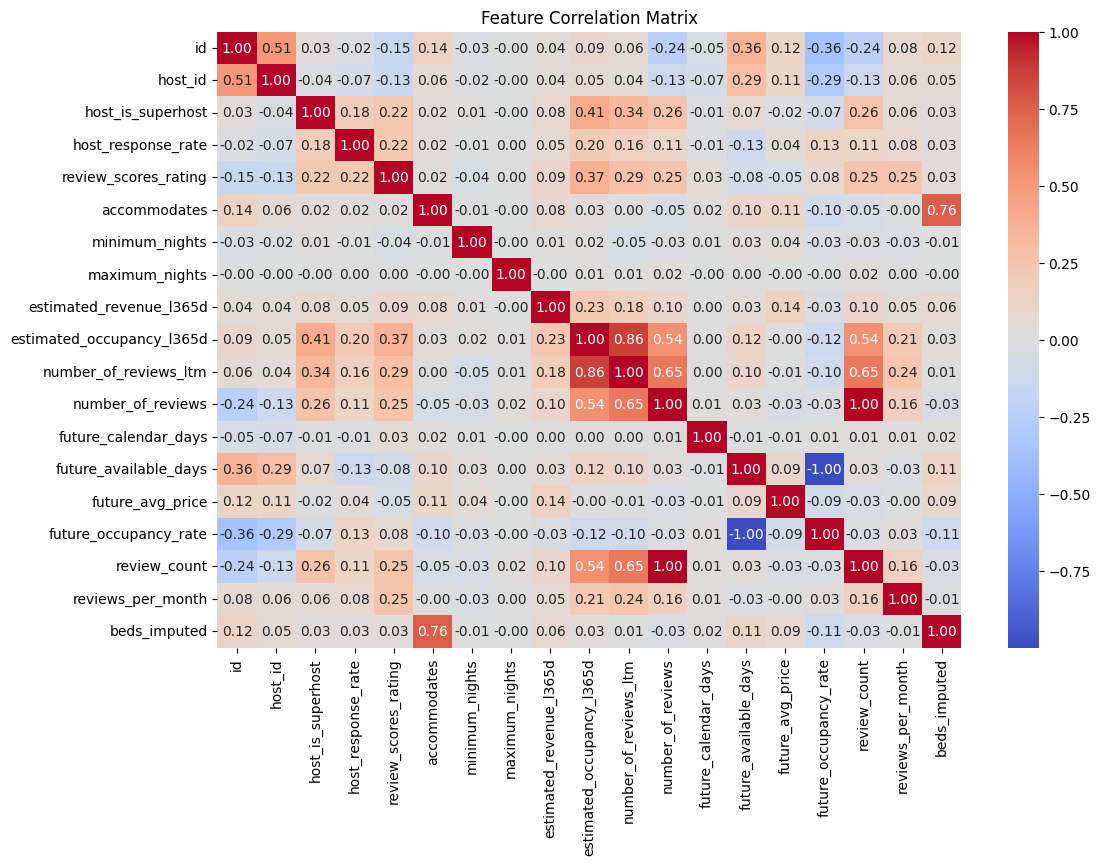

In [9]:
# ---------------------------------------------------------
# Correlation Matrix: Numeric Features
# Purpose: Quantify linear relationships between features.
# Helps identify redundancy, multicollinearity, and potential drivers.
# Useful for feature selection and understanding clustering behavior.
# ---------------------------------------------------------

# Select numeric columns (float and int types only)
numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns

# Compute Pearson correlation matrix
corr = df[numeric_cols].corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

# Add title and show plot
plt.title("Feature Correlation Matrix")
plt.show()

🔍 High Correlations (r > 0.9)
- number_of_reviews ↔ number_of_reviews_ltm (r = 0.97)
→ These are nearly duplicates — consider dropping one for clustering
- future_available_days ↔ future_calendar_days
→ Strong structural link — availability is bounded by calendar span

📈 Moderate Correlations (r ≈ 0.5–0.7)
- estimated_revenue_l365d ↔ estimated_occupancy_l365d
→ Occupancy is a key revenue driver — confirms earlier pairplot insight
- reviews_per_month ↔ review_count
→ Engagement velocity aligns with total review volume

⚠️ Low or No Correlation
- host_is_superhost, host_response_rate, review_scores_rating
→ These behavioral flags don’t strongly correlate with revenue or occupancy
→ Still useful for segmentation, but not predictive on their own

🧠 Strategic Implications
- Drop or consolidate highly correlated features to reduce dimensionality
- Focus on occupancy, review velocity, and pricing for clustering
- Use flags like superhost and review score for profiling, not clustering
Let me know if you want to filter this matrix to just ML features or prep it for PCA. You’re building a pipeline that’s lean, interpretable, and business-aware.


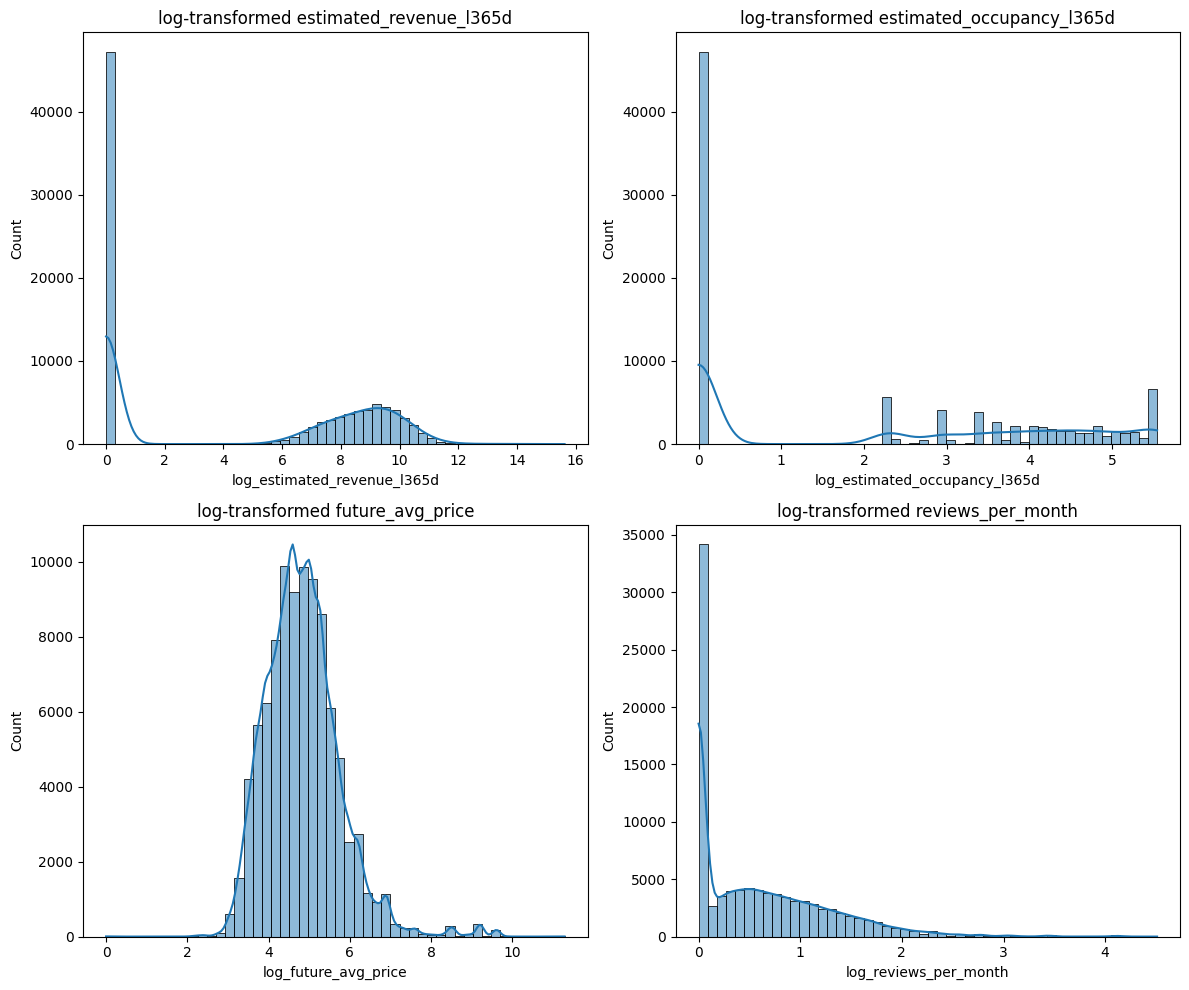

In [10]:
# ---------------------------------------------------------
# STEP 6: Log Transform Skewed Features
# Purpose: Normalize heavy-tailed distributions
# ---------------------------------------------------------


# Apply log1p to skewed features
skewed_cols = ["estimated_revenue_l365d", "estimated_occupancy_l365d", "future_avg_price","reviews_per_month"]

for col in skewed_cols:
    df[f"log_{col}"] = np.log1p(df[col])

# Plot transformed distributions
plt.figure(figsize=(12, 10))
for i, col in enumerate(skewed_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[f"log_{col}"], bins=50, kde=True)
    plt.title(f"log-transformed {col}")
plt.tight_layout()
plt.show()

In [11]:
# ---------------------------------------------------------
# Encode categorical features
# Purpose: Convert non-numeric columns into usable format
# CONSIDERING NEIGHBOURHOOD CLEANSED HERE
# ---------------------------------------------------------

# Encode superhost flag (already binary but ensure it's clean)
df["superhost_flag"] = df["host_is_superhost"].astype(int)

# One-hot encode room_type (drop_first to avoid dummy trap)
df = pd.get_dummies(df, columns=["room_type"], drop_first=True)

In [12]:
# ---------------------------------------------------------
# Select features for clustering
# Purpose: Build a clean feature matrix with behavioral signals
# Includes listing size via beds_imputed to capture property scale
# ---------------------------------------------------------

features = [
    "log_estimated_revenue_l365d",     # Earning potential
    "log_estimated_occupancy_l365d",   # Booking frequency
    "log_future_avg_price",            # Pricing strategy
    "log_reviews_per_month",           # Engagement velocity
    "review_scores_rating",            # Guest satisfaction
    "superhost_flag",                  # Host professionalism
    "beds_imputed",                    # Listing size / capacity proxy
    "room_type_Private room",          # Structural segmentation
    "room_type_Shared room",
    "room_type_Hotel room"
]

# Drop rows with any NaNs in selected features
df_clean = df.dropna(subset=features)

# Extract feature matrix
X = df_clean[features].copy()

In [13]:
# ---------------------------------------------------------
# Check how many rows were dropped due to missing values
# ---------------------------------------------------------

# Total rows before filtering
original_rows = df.shape[0]

# Rows remaining after dropping NaNs in clustering features
clean_rows = df.dropna(subset=features).shape[0]

# Number and percentage of rows dropped
dropped_rows = original_rows - clean_rows
drop_pct = dropped_rows / original_rows * 100

print(f"Dropped {dropped_rows} rows ({drop_pct:.2f}%) due to missing clustering features.")

Dropped 10 rows (0.01%) due to missing clustering features.


In [14]:
# ---------------------------------------------------------
# Scale features for clustering
# Purpose: Normalize feature ranges for distance-based algorithms
# ---------------------------------------------------------
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
from sklearn.mixture import GaussianMixture

# Fit GMM with 5 components (same as KMeans for comparison)
gmm = GaussianMixture(n_components=5, random_state=42)
cluster_labels = gmm.fit_predict(X_scaled)

# Attach cluster labels to DataFrame
df_clean = df_clean.copy()
df_clean["cluster"] = cluster_labels

In [16]:
# Get probabilities for each cluster
probs = gmm.predict_proba(X_scaled)

# Example: attach max probability for each listing
df_clean["cluster_confidence"] = probs.max(axis=1)

# Optional: flag fuzzy listings
df_clean["is_fuzzy"] = df_clean["cluster_confidence"] < 0.6

c:\Users\emand\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


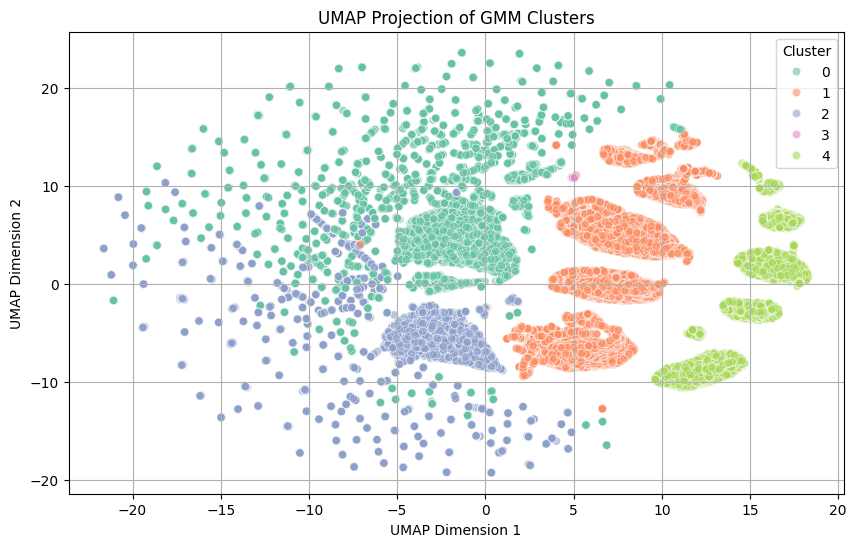

In [17]:
# ---------------------------------------------------------
# UMAP Projection for GMM Clusters
# ---------------------------------------------------------
import umap.umap_ as umap
import seaborn as sns
import matplotlib.pyplot as plt

reducer = umap.UMAP(init="pca", random_state=42)
embedding = reducer.fit_transform(X_scaled)

# Plot GMM clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=df_clean["cluster"], palette="Set2", alpha=0.6)
plt.title("UMAP Projection of GMM Clusters")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

In [18]:
# ---------------------------------------------------------
# Cluster Profiling for GMM Segmentation
# ---------------------------------------------------------
features_real = [
    "estimated_revenue_l365d",
    "estimated_occupancy_l365d",
    "future_avg_price",
    "reviews_per_month",
    "review_scores_rating",
    "superhost_flag",
    "beds_imputed"
]

df_clean.groupby("cluster")[features_real].mean().round(2)

,estimated_revenue_l365d,estimated_occupancy_l365d,future_avg_price,reviews_per_month,review_scores_rating,superhost_flag,beds_imputed
cluster,,,,,,,
0,0.00,0.00,375.94,0.79,2.32,0.06,2.14
1,13490.97,75.89,307.49,1.92,4.60,0.00,1.96
2,0.00,0.00,96.85,1.03,2.25,0.03,1.07
3,3305.82,61.35,169.98,2.20,3.33,0.11,3.88
4,18718.77,130.33,213.25,2.02,4.87,1.00,1.86


<Axes: xlabel='cluster_confidence', ylabel='Count'>

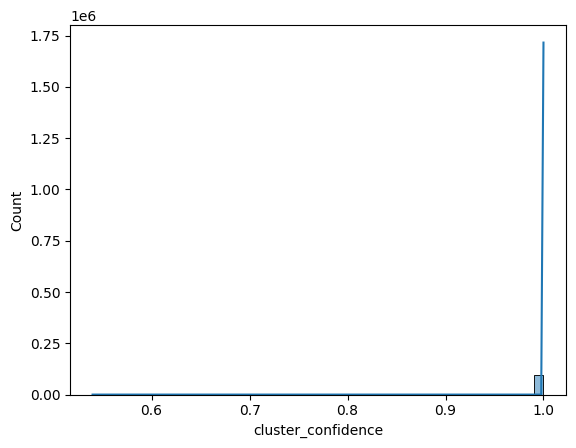

In [19]:
import seaborn as sns
sns.histplot(df_clean["cluster_confidence"], bins=50, kde=True)
